# IPN Cross-Correlation with Time-shifted GBM Lightcurves

This notebook demonstrates how to calculate an IPN localization using three GRB lightcurves from Fermi-GBM. In this tutorial, we will assume that each GBM lightcurve was observed by a different spacecraft and will input the relative time-shift ourselves.

The overall workflow is very similar to `CCF_Example2.ipynb`: we load the lightcurves, bin them, fit backgrounds, assign spacecraft positions, measure the relative time delays with the CCF, and then convert those delays into localization annuli. The main differences are that here we use explicitly time-shifted GBM lightcurves as stand-ins for separate spacecraft, we fit the background with RoboLowess instead of the polynomial background model used in `CCF_Example2.ipynb`, and we finish by comparing geocentric and barycentric localizations.

To get started, run the notebook cell below to load the data:

In [5]:
import warnings
warnings.filterwarnings("ignore")
from gdt.missions.fermi.gbm.tte import GbmTte

tte_n9 = GbmTte.open('data/glg_tte_n9_bn170206453_v00.fit')
tte_na = GbmTte.open('data/glg_tte_na_bn170206453_v00.fit')
tte_nb = GbmTte.open('data/glg_tte_nb_bn170206453_v00.fit')

## Shift the Lightcurves

The data above are the same GBM TTE files as used in `CCF_Example2.ipynb`. First, we will bin the data and shift the lightcurves in time. In the following cell, you can choose the binning timescales and how much you would like to shift the lightcurves. 

In [6]:
from gdt.core.binning.unbinned import bin_by_time
from gdt.core.data_primitives import TimeEnergyBins
from gdt.core.plot.lightcurve import Lightcurve
from gdt.missions.fermi.gbm.headers import PhaiiHeaders
from gdt.missions.fermi.gbm.phaii import Ctime

def shift_lightcurve(phaii, dt=0.):
    """Shift a lightcurve in time

    Args:
        phaii (`gdt.missions.fermi.gbm.phaii.Phaii`): lightcurve
        dt (float): amount of time you want to shift the lightcurve

    Returns:
        (`gdt.missions.fermi.gbm.phaii.Ctime`): lightcurve shifted in time
    """
    counts = phaii.data.counts
    tstart = phaii.data.tstart + dt
    tstop = phaii.data.tstop + dt
    bins = TimeEnergyBins(counts, tstart, tstop, (tstop - tstart), phaii.data.emin, phaii.data.emax)
    return Ctime.from_data(bins, headers=PhaiiHeaders(), detector=phaii.detector)

# choose the binning timescales [s]
timescale1 = 0.064
timescale2 = 0.256
timescale3 = 0.128

# bin the data
phaii1 = tte_n9.to_phaii(bin_by_time, timescale1)
phaii2 = tte_na.to_phaii(bin_by_time, timescale2)
phaii3 = tte_nb.to_phaii(bin_by_time, timescale3)

# choose how much to temporally shift lightcurve2 relative to lightcurve1
# shift2 must be < max_dt_12 (= 100 s) to avoid a degenerate 180-degree annulus.
shift2 = 95.
# same as above for lightcurve 3 relative to lightcurve1
shift3 = -20.

# shift lightcurves
phaii2 = shift_lightcurve(phaii2, dt=shift2)
phaii3 = shift_lightcurve(phaii3, dt=shift3)

# combine the full shifted lightcurves
phaiis = [phaii1, phaii2, phaii3]

### Fit the Background

This step plays the same role as in `CCF_Example2.ipynb`: we estimate the background for each lightcurve before running the CCF localization. The difference is the fitting strategy. `CCF_Example2.ipynb` uses explicit background intervals together with a polynomial background model, whereas here we use RoboLowess to estimate the background directly from the binned lightcurves.

To keep the fit fast, we first restrict the data to a shorter time window around the source intervals instead of fitting over the entire TTE span. We then estimate the background on a coarser time grid and interpolate that model back onto the original lightcurve bins used for the CCF.

Note: Gaussian+Exponential refinement failed. Using Pass 2 background model.


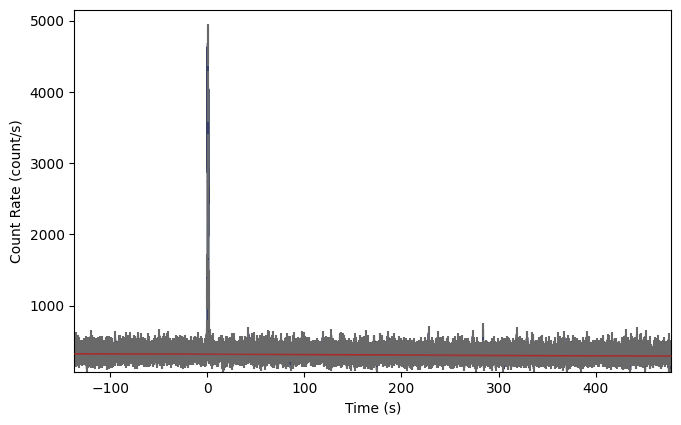

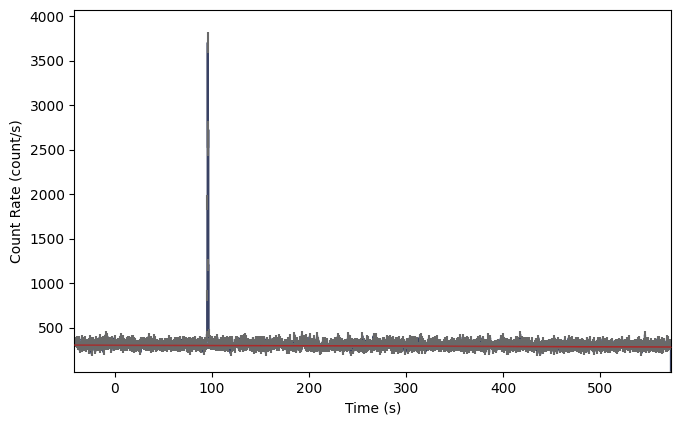

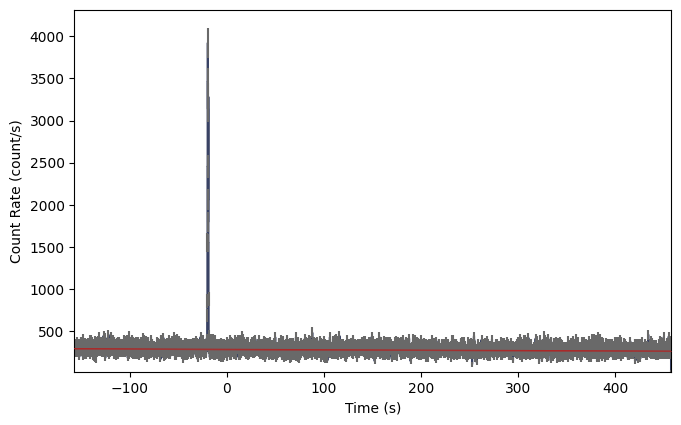

In [7]:
from gdt.core.background.binned import RoboLowess
from gdt.core.background.primitives import BackgroundRates
from gdt.core.binning.binned import rebin_by_time
import matplotlib.pyplot as plt 

# define the energy range & a coarser temporal resolution for the background fitting
energy_range = (50.0, 300.0)
common_chan_range = (33, 85)
Time_binned_bg = 1.024

def fit_background_on_coarse_bins(phaii, dt_bg):
    fine_data = phaii.data
    bg_phaii = phaii.rebin_time(rebin_by_time, dt_bg)
    bg_data = bg_phaii.data

    fitter = RoboLowess(bg_data.counts, bg_data.tstart, bg_data.tstop, bg_data.exposure,
                        first_pass_chan_range=common_chan_range)
    fitter.fit(win_size=None,lowess_iter=2)

    rates, rate_uncert = fitter.interpolate(fine_data.tstart, fine_data.tstop)
    bkgd_model = BackgroundRates(rates, rate_uncert, fine_data.tstart, fine_data.tstop,
                                 fine_data.emin, fine_data.emax, exposure=fine_data.exposure)
    return bg_phaii, fitter, bkgd_model

# Fit on coarser bins, then evaluate the background on the original lightcurve bins.
bg_phaiis = []
bkgd_fitters = []
bkgd_models = []

for phaii in phaiis:
    bg_phaii, bkgd_fitter, bkgd_model = fit_background_on_coarse_bins(phaii, Time_binned_bg)
    bg_phaiis.append(bg_phaii)
    bkgd_fitters.append(bkgd_fitter)
    bkgd_models.append(bkgd_model)

# plot the lightcurves
lcplots = [Lightcurve(data=phaii.to_lightcurve(energy_range=energy_range),
                     background=bkgd_model.integrate_energy(*energy_range))
                     for phaii, bkgd_model in zip(phaiis, bkgd_models)]

plt.show()

## Spacecraft Geometry

In `CCF_Example2.ipynb`, the spacecraft positions are simple schematic examples sufficient to demonstrate the CCF workflow. Here we assign explicit geocentric Cartesian positions so that the recovered time delays are consistent with the artificial shifts we inserted into the lightcurves.

The baselines are deliberately set to ~249 light-seconds each (~74.8 million km, ≈ 0.5 AU), placing spacecraft 2 and 3 at interplanetary distances. These are not realistic mission positions; they are chosen to illustrate two effects that only emerge at large separations:

- **Narrow annuli.** The 1σ half-width of an IPN annulus scales as $\sigma_\theta \propto 1/D$. At 0.5 AU the rings are only about 1 arcminute wide — far more precise than typical near-Earth IPN.
- **Significant barycentric correction.** Earth's ~30 km/s orbital velocity shifts the effective baseline direction by an amount comparable to the annulus width once $D$ is large, so using the correct solar-system barycentric frame becomes necessary.

Using full 3D position vectors is also essential for the geocentric-versus-barycentric comparison below.


In [25]:
from gdt.ipn.instrument import *

# store the lightcurves and background as observations
observations = [Observation(phaii.to_lightcurve(energy_range=energy_range),
                    background=bkgd_model.integrate_energy(*energy_range))
                        for phaii, bkgd_model in zip(phaiis, bkgd_models)]

# Place sc1 at the geocenter so that the inter-spacecraft distances
# equal exactly the light-travel-times stated in the comments.
scpos1 = SpacecraftPosition.from_vectors([0.0, 0.0, 0.0], [0.0, 0.0, 0.0])  # geocenter

# Spacecraft 2: 74,800,000 km along x (~249 s light-travel-time, ≈ 0.5 AU from geocenter)
scpos2 = SpacecraftPosition.from_vectors([74800000.0, 0.0, 0.0], [0.0, 0.0, 0.0])

# Spacecraft 3: 74,800,000 km along -y (~249 s light-travel-time, ≈ 0.5 AU from geocenter).
# The -20 s delay for pair 1-3 is 8% of the maximum (20/249), so annulus 2 has a
# radius of ~95 deg from the -y axis that intersects annulus 1 (~68 deg from the +x axis).
scpos3 = SpacecraftPosition.from_vectors([0.0, -74800000.0, 0.0], [0.0, 0.0, 0.0])


spacecraft1 = Spacecraft(scpos1)
spacecraft2 = Spacecraft(scpos2)
spacecraft3 = Spacecraft(scpos3)
spacecraft = [spacecraft1, spacecraft2, spacecraft3]
_ = [spcft.set_observation(observation) for spcft, observation in zip(spacecraft, observations)]


## Find the time delays

Now we will calculate the time delays between pairs of our lightcurves similar to what was done in `CCF_Example2.ipynb`.

The source intervals (`src1`, `src2`, `src3`) define the time windows containing the burst emission in each lightcurve. You identify these by inspecting the lightcurve plots above: the burst in the unshifted lightcurve (n9) peaks near t = 0 s, so `src1 = (-1, 3)` captures that emission. Because we shifted lightcurve 2 by +95 s and lightcurve 3 by −20 s, the same burst appears at (−1+95, 3+95) ≈ (93, 98) s and (−1−20, 3−20) ≈ (−23, −18) s respectively. The CCF then searches for the lag that best aligns the burst signal between each pair of lightcurves.


Geometric max_dt pair 1-2 = 249.5 s  (capped to 129.8 s by data length)
Geometric max_dt pair 1-3 = 249.5 s  (capped to 108.8 s by data length)


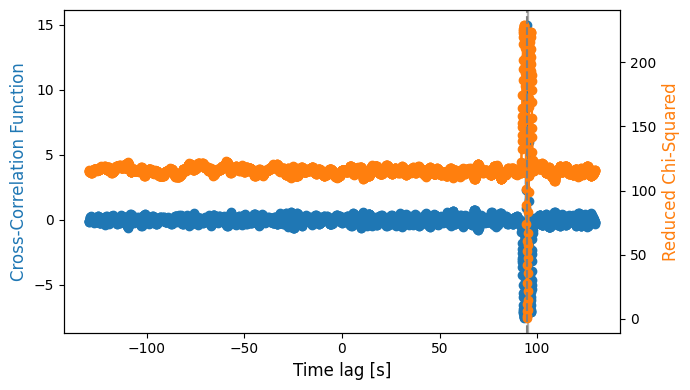

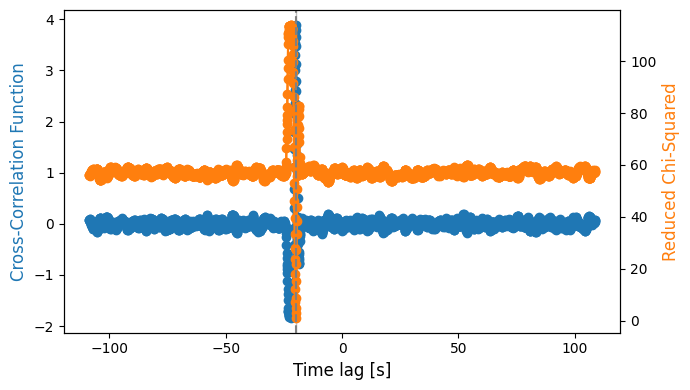

Time offset: 95.040 (+0.064, -0.064)
Time offset: -19.904 (+0.064, -0.064)
CCF runtime pair 1-2: 0.645 s
CCF runtime pair 1-3: 0.948 s
CCF runtime total : 1.592 s


In [ ]:
from gdt.ipn.algorithms.ccf import Ipn
from time import perf_counter

# Set the CCF intervals for each lightcurve
src1 = (-1., 3.0)
src2 = (93., 98.)
src3 = (-23., -18.)

# initialize the IPN with the lightcurve observations
ipn1 = Ipn.from_list([spacecraft1, spacecraft2])  # lightcurve 1 and lightcurve 2
ipn2 = Ipn.from_list([spacecraft1, spacecraft3])  # lightcurve 1 and lightcurve 3

# Derive max shift from spacecraft geometry (light-travel-time baseline)
max_dt_12, _ = spacecraft1.position.light_travel_time(spacecraft2.position)
max_dt_13, _ = spacecraft1.position.light_travel_time(spacecraft3.position)

# The CCF requires BOTH lightcurves to span (src_start - max_dt, src_stop + max_dt).
# At 0.5 AU the geometric max_dt (~249 s) exceeds what the 614 s TTE file can support,
# so we cap max_dt by the maximum lag the data can support in each pair.
# The true delays (95 s and 20 s) remain well within the capped range.
lc1_t0 = phaiis[0].time_range[0]
lc2_t0 = phaiis[1].time_range[0]
lc3_t0 = phaiis[2].time_range[0]
max_dt_from_data_12 = min(src2[0] - lc1_t0, src2[0] - lc2_t0) - 5.
max_dt_from_data_13 = min(src3[0] - lc1_t0, src3[0] - lc3_t0) - 5.
max_dt_search_12 = min(max_dt_12 + 5., max_dt_from_data_12)
max_dt_search_13 = min(max_dt_13 + 5., max_dt_from_data_13)

print(f'Geometric max_dt pair 1-2 = {max_dt_12:.1f} s  (capped to {max_dt_search_12:.1f} s by data length)')
print(f'Geometric max_dt pair 1-3 = {max_dt_13:.1f} s  (capped to {max_dt_search_13:.1f} s by data length)')

# run CCF
start = perf_counter()
ipn1.localize(src1, src2, max_dt=max_dt_search_12, plot=False)
t_mid = perf_counter()
ipn2.localize(src1, src3, max_dt=max_dt_search_13, plot=False)
stop = perf_counter()

# plot the fit of the CCF and chisq for each time shift
ipn1.plot_fit()
ipn2.plot_fit()

# the time offset and error
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn1.time_offset.dt, ipn1.time_offset.err[1], ipn1.time_offset.err[0]))
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn2.time_offset.dt, ipn2.time_offset.err[1], ipn2.time_offset.err[0]))
print(f'CCF runtime pair 1-2: {t_mid - start:.3f} s')
print(f'CCF runtime pair 1-3: {stop - t_mid:.3f} s')
print(f'CCF runtime total : {stop - start:.3f} s')


For our first pair of lightcurves, we recover a time offset very close to the input shift of +95 s (on a ~249 s light-travel-time baseline along x). For our second pair of lightcurves, the recovered offset is very close to the input shift of -20 s (consistent with the ~249 s baseline along -y).


## Geocentric vs Barycentric Baselines

The IPN annulus is defined by the direction of the baseline vector between two spacecraft and the light-travel-time delay. Its 1σ half-width is set by the CCF timing uncertainty $\sigma_{dt}$:

$$\sigma_\theta = \frac{c \, \sigma_{dt}}{D \sin\theta}$$

where $D$ is the inter-spacecraft distance and $\theta$ is the angle between the source and the baseline. With a ~249-light-second baseline ($D \approx 0.5$ AU) and $\sigma_{dt} \approx 0.064$ s (one lightcurve bin), both pairs produce narrow rings of similar width: pair 1-2 has the source at $\theta \approx 68°$ from its baseline, giving $\sigma_\theta \approx 1$ arcmin, while pair 1-3 has the source nearly perpendicular ($\theta \approx 95°$), also giving $\sigma_\theta \approx 1$ arcmin. The rings therefore appear as very narrow bands — a direct consequence of the long baseline.

That same precision makes the choice of reference frame matter. At interplanetary distances the correct frame is the solar-system barycenter, not the geocenter. With the schematic spacecraft here assigned zero velocity, only Earth's ~30 km/s orbital motion enters — shifting the baseline direction by ~0.10 arcmin (~10% of the ring width). In a real scenario with a fast-moving spacecraft such as Parker Solar Probe (~190 km/s at perihelion), the relative velocity between the two instruments shifts the baseline by ~0.74 arcmin — roughly 75% of the ring width — making the barycentric correction essential for an accurate localization. Each spacecraft's barycentric position is also evaluated at its own observation time, since the two detectors record the burst at slightly different moments.

Below, we compare the geocentric and barycentric baseline directions, generate both localizations with `ipn.get_healpix()`, and plot the barycentric annuli.


Pair 1-2 geocentric  baseline: RA=180.000°  Dec=0.000°
Pair 1-2 bary (Earth-only):    RA=180.001°  Dec=-0.001°  shift=0.10 arcmin
Pair 1-2 bary + sc2 at 190km/s:RA=179.988°  Dec=-0.001°  shift=0.74 arcmin


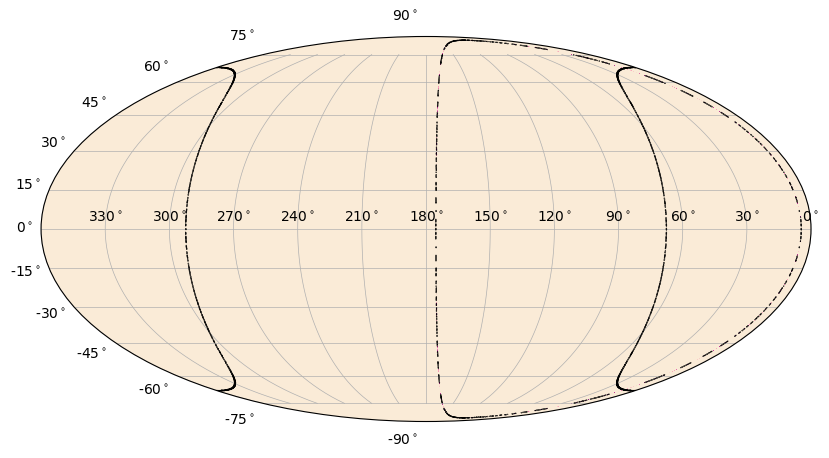

In [31]:
from astropy.time import Time, TimeDelta
from gdt.core.plot.sky import EquatorialPlot
from gdt.core.healpix import HealPixLocalization

# set the map resolution
nside = 1024

# Choose an absolute reference time near the burst.
# dt = t(sc1) - t(sc_other), therefore
# t(sc_other) = t(sc1) - dt
t_ref = Time('2017-02-06T10:52:14', scale='utc')

t1_12 = t_ref
t2_12 = t_ref - TimeDelta(ipn1.time_offset.dt, format='sec')
t1_13 = t_ref
t3_13 = t_ref - TimeDelta(ipn2.time_offset.dt, format='sec')

# PSP-like velocity for spacecraft 2 (190 km/s along Y at perihelion)
vel_psp = [0., 190., 0.]  # km/s

# Compare geocentric, barycentric (Earth-only), and barycentric with sc2 velocity
geo12_ra,  geo12_dec  = spacecraft1.baseline_to(spacecraft2)
bary12_ra, bary12_dec = spacecraft1.baseline_to(spacecraft2, obstime=t1_12, other_obstime=t2_12, barycentric=True)
bary12_vel_ra, bary12_vel_dec = spacecraft1.baseline_to(spacecraft2, obstime=t1_12, other_obstime=t2_12,
                                                         barycentric=True, other_vel_vec=vel_psp, ref_time=t1_12)

from astropy.coordinates import SkyCoord
import astropy.units as u
sep_eo  = SkyCoord(np.rad2deg(geo12_ra)*u.deg,  np.rad2deg(geo12_dec)*u.deg).separation(
          SkyCoord(np.rad2deg(bary12_ra)*u.deg, np.rad2deg(bary12_dec)*u.deg)).to(u.arcmin).value
sep_vel = SkyCoord(np.rad2deg(geo12_ra)*u.deg,  np.rad2deg(geo12_dec)*u.deg).separation(
          SkyCoord(np.rad2deg(bary12_vel_ra)*u.deg, np.rad2deg(bary12_vel_dec)*u.deg)).to(u.arcmin).value

print(f'Pair 1-2 geocentric  baseline: RA={np.rad2deg(geo12_ra):.3f}°  Dec={np.rad2deg(geo12_dec):.3f}°')
print(f'Pair 1-2 bary (Earth-only):    RA={np.rad2deg(bary12_ra):.3f}°  Dec={np.rad2deg(bary12_dec):.3f}°  shift={sep_eo:.2f} arcmin')
print(f'Pair 1-2 bary + sc2 at 190km/s:RA={np.rad2deg(bary12_vel_ra):.3f}°  Dec={np.rad2deg(bary12_vel_dec):.3f}°  shift={sep_vel:.2f} arcmin')

# Generate the two final barycentric maps (velocity-corrected for pair 1-2, Earth-only for pair 1-3)
hpx1_bary_vel = ipn1.get_healpix(nside=nside, obstime=t1_12, other_obstime=t2_12, barycentric=True,
                                   other_vel_vec=vel_psp, ref_time=t1_12)
hpx2_bary     = ipn2.get_healpix(nside=nside, obstime=t1_13, other_obstime=t3_13, barycentric=True)

# Also keep the Earth-only pair 1-2 map for the joint probability cell below
hpx1_bary = ipn1.get_healpix(nside=nside, obstime=t1_12, other_obstime=t2_12, barycentric=True)

# Plot the two barycentric annuli
skyplot_bary = EquatorialPlot()
skyplot_bary.add_localization(hpx1_bary_vel, clevels=[0.90], gradient=True,
                              sun=False, earth=False, detectors=[], galactic_plane=False)
skyplot_bary.add_localization(hpx2_bary, clevels=[0.68], gradient=True,
                              sun=False, earth=False, detectors=[], galactic_plane=False)
for skyline in skyplot_bary._clevels:
    skyline.linewidth = 0.8

plt.show()
plt.close()


## Joint Localization

Here we combine the two barycentric annulus maps into a single joint probability map.

Each annulus from a detector pair constrains the source to a ring on the sky. With two independent pairs sharing a common spacecraft, we obtain two annuli whose intersection narrows the localization to two compact regions. We form the joint probability map by multiplying the two barycentric annulus maps pixel-by-pixel and renormalizing — the resulting map retains only the sky positions consistent with **both** time delays simultaneously.

The map below shows the joint probability on a full-sky Mollweide projection. The localization reduces to two candidate positions — symmetric about the celestial equator near RA ≈ 0°, Dec ≈ ±58° — where both annuli cross. A display smoothing (5° FWHM) is applied so the spots are visible at full-sky scale; the true 68%/90% confidence regions are sub-arcminute to arcminute scale.


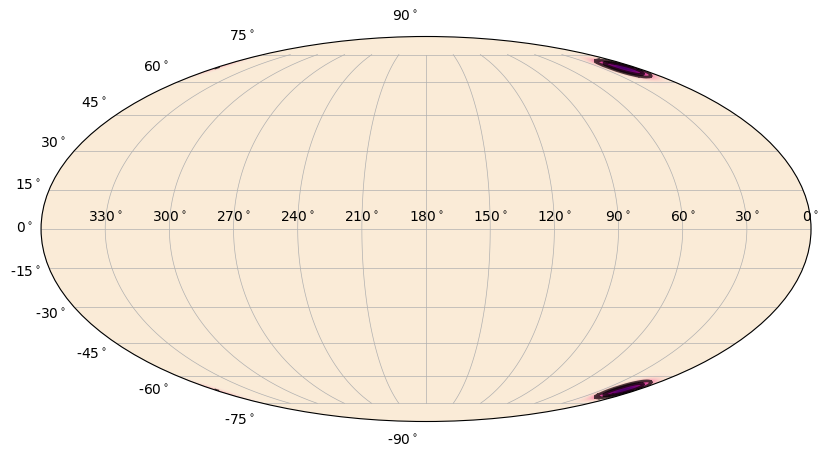

In [ ]:
import healpy as hp

joint = hpx1_bary.prob * hpx2_bary.prob;  joint /= joint.sum()
# Smooth for display only — the true rings are arcmin-wide, so a 5° FWHM
# kernel is applied purely to make the two spots visible at full-sky scale.
smooth = np.clip(hp.smoothing(joint, fwhm=np.deg2rad(5.0), verbose=False), 0, None)
joint_hpx = HealPixLocalization.from_data(smooth / smooth.sum())

skyplot = EquatorialPlot()
skyplot.add_localization(joint_hpx, clevels=[0.68, 0.90], gradient=True,
                         sun=False, earth=False, detectors=[], galactic_plane=False)
plt.show()
plt.close()


## Summary

This notebook demonstrated how to compute an IPN localization from artificially time-shifted GBM lightcurves:

1. **Shift & bin** — three TTE files are binned and shifted to mimic multi-spacecraft observations with known delays.
2. **Background fitting** — RoboLowess estimates the background on a coarser time grid and interpolates back to the original bins.
3. **CCF localization** — the cross-correlation function recovers the input delays and converts them to two narrow annuli (~1 arcmin wide at 0.5 AU baselines).
4. **Geocentric vs. barycentric** — at 0.5 AU baselines Earth's orbital velocity shifts the annulus by ~0.10 arcmin (~10% of the ring width); a fast spacecraft like PSP at perihelion adds a further ~0.74 arcmin shift (~75% of the ring width), making the barycentric correction essential.
5. **Joint probability** — multiplying the two barycentric annulus maps yields two compact candidate sky positions where both rings intersect.
